# P002 MI 基准测试结果可视化

本notebook用于从P002-MI文件夹下的JSON结果文件中读取数据并绘制多指标比较图表。


In [8]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置绘图风格
plt.style.use('default')
sns.set_palette("Set2")

print("导入完成！")


导入完成！


## 1. 读取JSON结果文件


In [9]:
def load_results_from_json(results_dir: str = "../rna-spatial-benchmark/P002-MI") -> Dict[str, Dict]:
    """
    从指定目录加载所有JSON结果文件
    
    Args:
        results_dir: JSON结果文件所在目录
        
    Returns:
        Dict: 包含所有方法结果的字典
    """
    results_data = {}
    
    if not os.path.exists(results_dir):
        print(f"结果目录 {results_dir} 不存在")
        return results_data
    
    # 查找所有JSON结果文件
    json_files = [f for f in os.listdir(results_dir) if f.startswith('MI-') and f.endswith('-final-results.json')]
    
    print(f"找到 {len(json_files)} 个结果文件:")
    for json_file in json_files:
        print(f"  - {json_file}")
    
    for json_file in json_files:
        # 提取方法名: MI-{method}-final-results.json -> {method}
        method = json_file.replace('MI-', '').replace('-final-results.json', '')
        filepath = os.path.join(results_dir, json_file)
        
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                data = json.load(f)
                results_data[method] = data
                print(f"成功加载 {method} 的结果")
        except Exception as e:
            print(f"加载 {method} 结果时出错: {e}")
    
    return results_data

# 加载结果数据
results_data = load_results_from_json()
print(f"\n总共加载了 {len(results_data)} 个方法的结果")


找到 6 个结果文件:
  - MI-scfugw-final-results.json
  - MI-gimvi-final-results.json
  - MI-spage-final-results.json
  - MI-novosparc-final-results.json
  - MI-tangram-final-results.json
  - MI-spaotsc-final-results.json
成功加载 scfugw 的结果
成功加载 gimvi 的结果
成功加载 spage 的结果
成功加载 novosparc 的结果
成功加载 tangram 的结果
成功加载 spaotsc 的结果

总共加载了 6 个方法的结果


## 2. 数据预处理和格式化


In [10]:
def extract_average_results(results_data: Dict[str, Dict]) -> Dict[str, List[float]]:
    """
    从结果数据中提取平均结果
    
    Args:
        results_data: 包含所有方法结果的字典
        
    Returns:
        Dict: 格式为 {'算法名': [PCC, JS, SSIM, RMSE]} 的字典
    """
    formatted_data = {}
    
    for method, data in results_data.items():
        if 'dataset_average' in data:
            avg_results = data['dataset_average']
            # 按照指定顺序提取指标: [PCC, JS, SSIM, RMSE]
            formatted_data[method.upper()] = [
                avg_results.get('PCC', 0),
                avg_results.get('JS', 0),
                avg_results.get('SSIM', 0),
                avg_results.get('RMSE', 0)
            ]
            print(f"{method.upper()}: PCC={avg_results.get('PCC', 0):.4f}, JS={avg_results.get('JS', 0):.4f}, SSIM={avg_results.get('SSIM', 0):.4f}, RMSE={avg_results.get('RMSE', 0):.4f}")
        else:
            print(f"警告: {method} 没有找到平均结果数据")
    
    return formatted_data

# 提取平均结果
data = extract_average_results(results_data)
print(f"\n格式化后的数据包含 {len(data)} 个方法")


SCFUGW: PCC=0.2179, JS=0.9097, SSIM=0.1630, RMSE=1.2248
GIMVI: PCC=0.1025, JS=0.1716, SSIM=0.0943, RMSE=1.3199
SPAGE: PCC=0.2109, JS=0.1975, SSIM=0.1639, RMSE=1.2470
NOVOSPARC: PCC=0.1334, JS=0.9143, SSIM=0.1137, RMSE=1.2939
TANGRAM: PCC=0.0430, JS=0.1584, SSIM=0.0463, RMSE=1.3694
SPAOTSC: PCC=0.2200, JS=0.9113, SSIM=0.1783, RMSE=1.2273

格式化后的数据包含 6 个方法


## 3. 绘制多指标比较图表


/tmp/ipykernel_1281825/1067612946.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1281825/1067612946.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1281825/1067612946.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1281825/1067612946.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


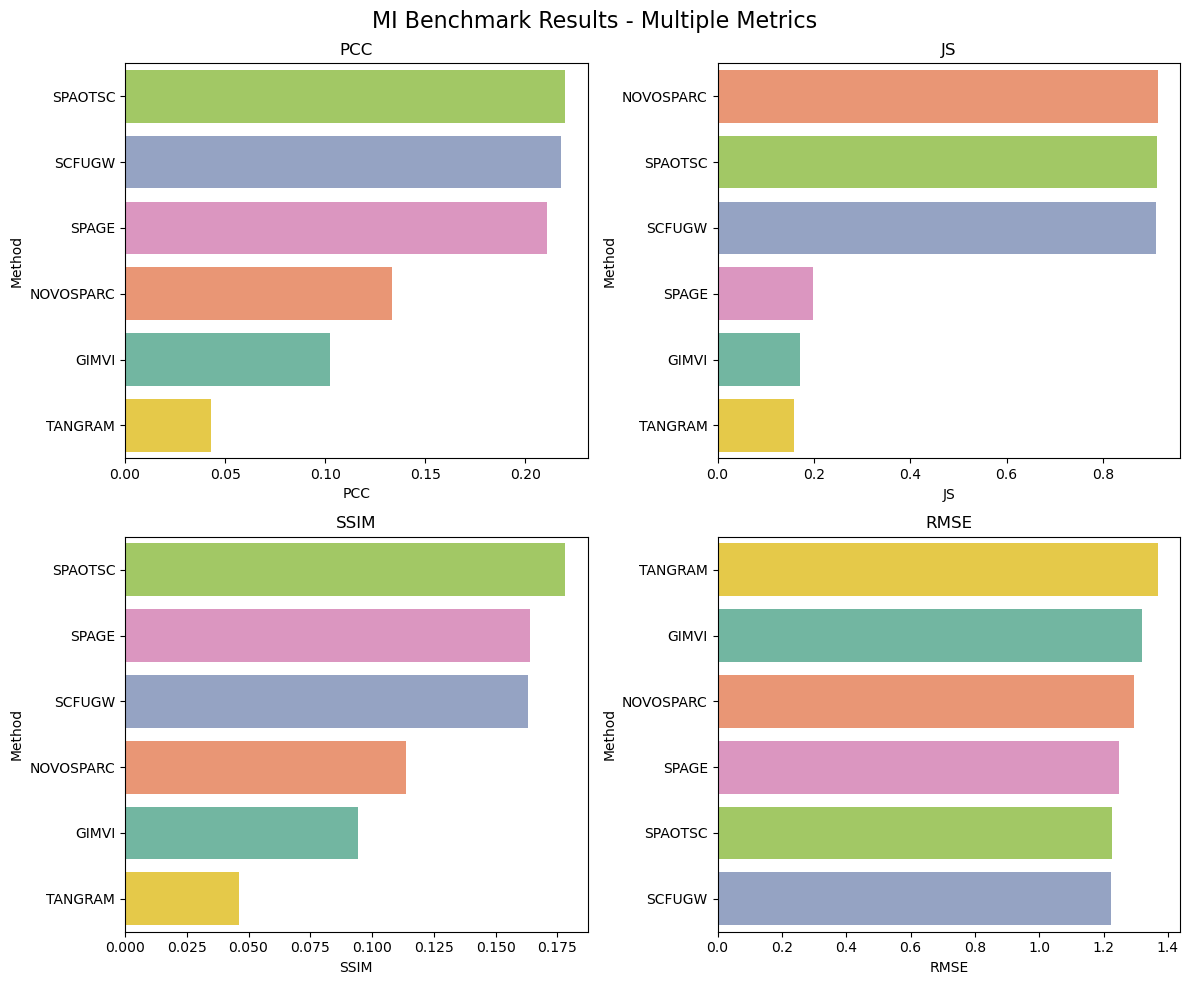

图表已保存为: MI_multi_metrics_benchmark.png


In [12]:
# 设置随机种子，保证结果可复现
np.random.seed(42)

# 指标名称
metrics = ['PCC', 'JS', 'SSIM', 'RMSE']

# 获取所有算法名称，并创建固定的颜色映射
all_tools = sorted(list(data.keys()))  # 按字母顺序排序，确保颜色映射稳定
palette_colors = sns.color_palette("Set2", n_colors=len(all_tools))
color_map = dict(zip(all_tools, palette_colors))

# 创建子图
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# 为每个指标绘制柱状图
for i, metric in enumerate(metrics):
    # 提取当前指标的数据
    tools_list = list(data.keys())
    values_list = [data[tool][i] for tool in tools_list]
    
    # 创建DataFrame
    df = pd.DataFrame({
        'tool': tools_list,
        metric: values_list
    })
    
    # 按照当前指标的值从高到低排序
    df_sorted = df.sort_values(by=metric, ascending=False)
    tools_sorted = df_sorted['tool'].tolist()
    
    # 根据排序后的顺序，获取对应的颜色列表（保持每个算法的固定颜色）
    colors_sorted = [color_map[tool] for tool in tools_sorted]
    
    # 绘制横向柱状图（按值从高到低排序，但保持固定颜色）
    sns.barplot(
        data=df_sorted,
        x=metric,
        y="tool",
        palette=colors_sorted,
        ax=axes[i]
    )
    
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel("Method")
    axes[i].set_title(f"{metric}")

plt.suptitle("MI Benchmark Results - Multiple Metrics", fontsize=16)
plt.tight_layout()
plt.savefig('MI_multi_metrics_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()

print("图表已保存为: MI_multi_metrics_benchmark.png")


## 4. 绘制K-fold箱线图


In [13]:
def extract_fold_results(results_data: Dict[str, Dict]) -> pd.DataFrame:
    """
    从结果数据中提取每个fold的详细结果
    
    Args:
        results_data: 包含所有方法结果的字典
        
    Returns:
        pd.DataFrame: 包含所有fold结果的DataFrame
    """
    fold_data = []
    
    for method, data in results_data.items():
        if 'sample_results' in data:
            for sample_name, sample_data in data['sample_results'].items():
                if 'fold_results' in sample_data:
                    for fold_idx, fold_result in enumerate(sample_data['fold_results']):
                        fold_data.append({
                            'Method': method.upper(),
                            'Sample': sample_name,
                            'Fold': fold_idx + 1,
                            'PCC': fold_result['PCC'],
                            'JS': fold_result['JS'],
                            'SSIM': fold_result['SSIM'],
                            'RMSE': fold_result['RMSE']
                        })
    
    return pd.DataFrame(fold_data)

# 提取fold结果数据
fold_df = extract_fold_results(results_data)
print(f"提取了 {len(fold_df)} 个fold结果")
print(f"包含 {fold_df['Method'].nunique()} 个方法")
print(f"每个方法的fold数量: {fold_df.groupby('Method')['Fold'].count().to_dict()}")

# 显示前几行数据
print("\n前5行数据:")
print(fold_df.head())


提取了 1620 个fold结果
包含 6 个方法
每个方法的fold数量: {'GIMVI': 270, 'NOVOSPARC': 270, 'SCFUGW': 270, 'SPAGE': 270, 'SPAOTSC': 270, 'TANGRAM': 270}

前5行数据:
   Method                     Sample  Fold       PCC        JS      SSIM  \
0  SCFUGW  atac_rna_visium_FZ_GT_P19     1  0.433542  0.140034  0.311755   
1  SCFUGW  atac_rna_visium_FZ_GT_P19     2  0.393509  0.171994  0.270420   
2  SCFUGW  atac_rna_visium_FZ_GT_P19     3  0.388676  0.135461  0.264769   
3  SCFUGW  atac_rna_visium_FZ_GT_P19     4  0.421716  0.180038  0.254494   
4  SCFUGW  atac_rna_visium_FZ_GT_P19     5  0.473551  0.139973  0.334999   

       RMSE  
0  1.053963  
1  1.090514  
2  1.095547  
3  1.060894  
4  1.018164  


/tmp/ipykernel_1281825/1872012172.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1281825/1872012172.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1281825/1872012172.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1281825/1872012172.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


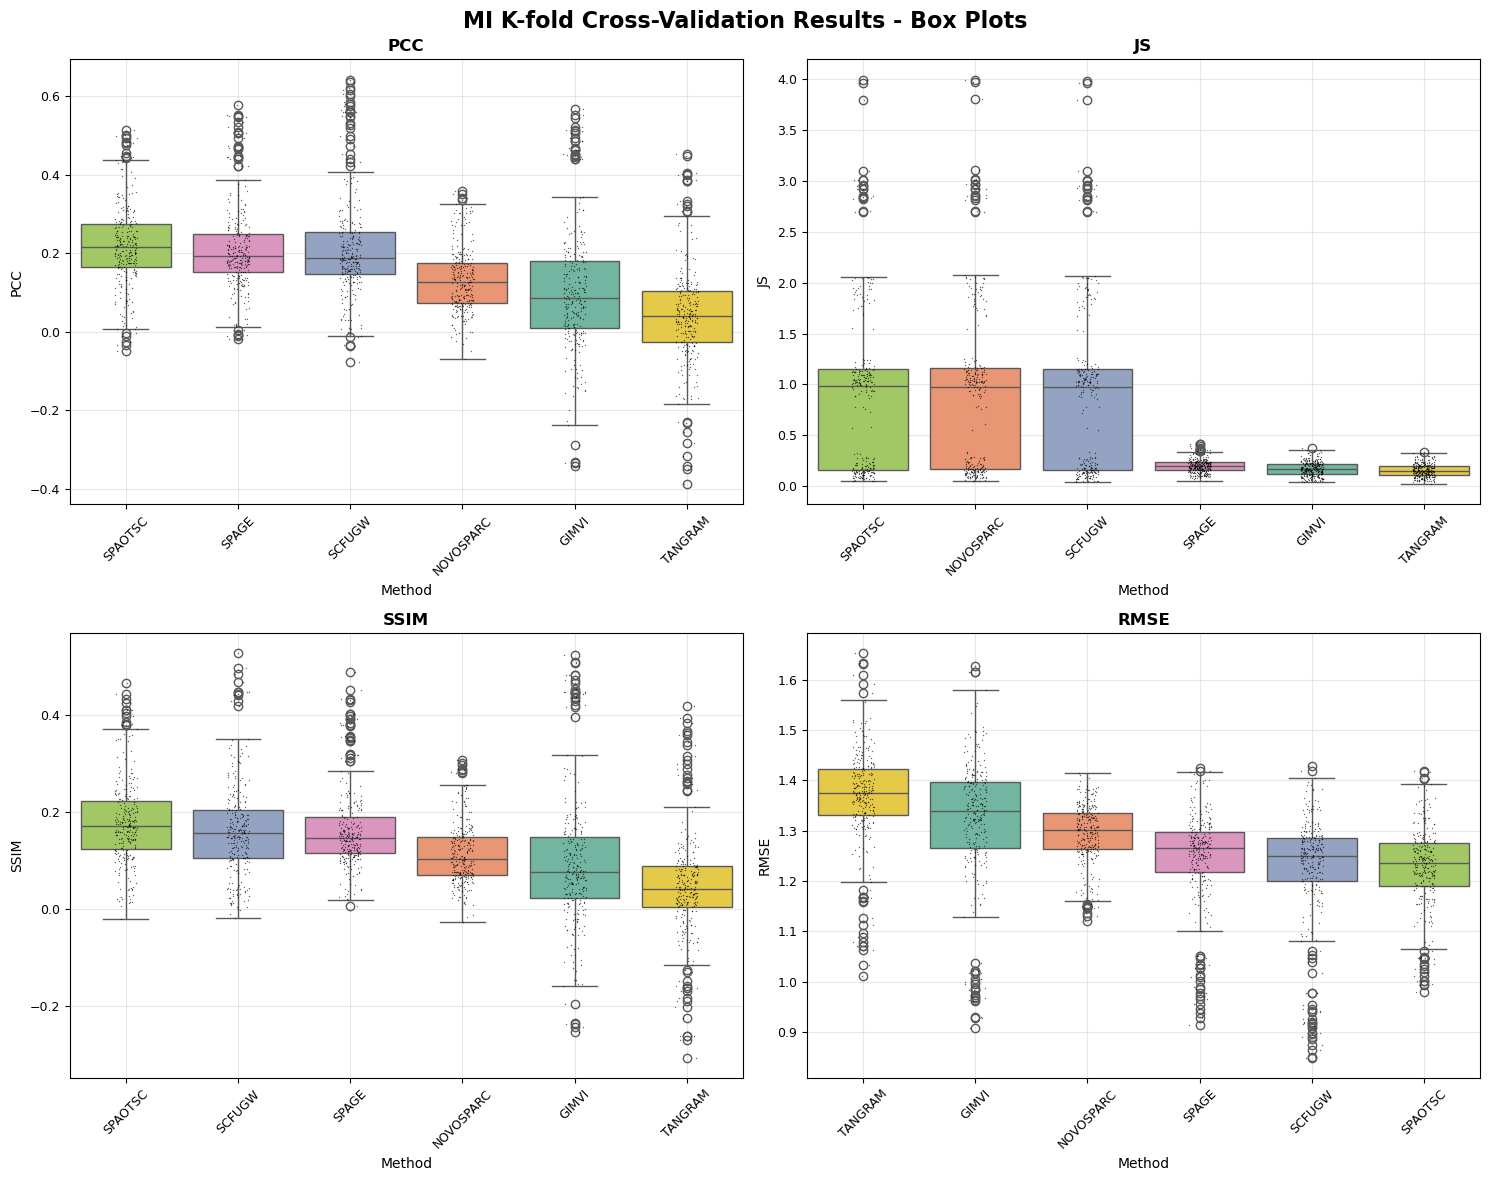

K-fold箱线图已保存为: MI_kfold_boxplots.png


In [14]:
# 创建与柱状图相同的颜色映射（确保颜色一致）
all_methods = sorted(fold_df['Method'].unique())  # 按字母顺序排序，确保颜色映射稳定
palette_colors = sns.color_palette("Set2", n_colors=len(all_methods))
color_map = dict(zip(all_methods, palette_colors))

# 绘制K-fold箱线图
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

metrics = ['PCC', 'JS', 'SSIM', 'RMSE']
titles = ['PCC', 'JS', 'SSIM', 'RMSE']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[i]
    
    # 计算每个方法的中位数，并按中位数从大到小排序
    median_values = fold_df.groupby('Method')[metric].median().sort_values(ascending=False)
    methods_sorted = median_values.index.tolist()
    
    # 根据排序后的顺序，获取对应的颜色列表（保持每个算法的固定颜色）
    colors_sorted = [color_map[method] for method in methods_sorted]
    
    # 绘制箱线图（按中位数从大到小排序，但保持固定颜色）
    sns.boxplot(
        data=fold_df,
        x='Method',
        y=metric,
        order=methods_sorted,  # 按中位数排序后的顺序
        palette=colors_sorted,  # 使用固定的颜色映射
        ax=ax
    )
    
    # 添加散点图显示每个fold的点（使用相同的顺序）
    sns.stripplot(
        data=fold_df,
        x='Method',
        y=metric,
        order=methods_sorted,  # 保持相同的顺序
        color='black',
        alpha=0.6,
        size=1,
        ax=ax
    )
    
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Method', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    
    # 添加网格
    ax.grid(True, alpha=0.3)

plt.suptitle('MI K-fold Cross-Validation Results - Box Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('MI_kfold_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("K-fold箱线图已保存为: MI_kfold_boxplots.png")


In [ ]:
# 统计每个方法的fold结果
print("=== K-fold结果统计 ===")
for method in fold_df['Method'].unique():
    method_data = fold_df[fold_df['Method'] == method]
    print(f"\n{method}:")
    for metric in metrics:
        values = method_data[metric]
        print(f"  {metric}: 均值={values.mean():.4f}, 标准差={values.std():.4f}, 范围=[{values.min():.4f}, {values.max():.4f}]")

# 导出fold结果到CSV
fold_df.to_csv('MI_kfold_detailed_results.csv', index=False)
print(f"\n详细fold结果已导出到: MI_kfold_detailed_results.csv")
print(f"总共 {len(fold_df)} 个fold结果")
